Loading weights: 100%|██████████| 223/223 [00:00<00:00, 8681.44it/s]
/Users/pahautelman/uni/master/DSAIT4030 Generative Modelling/spectrum-matching-project/.venv/lib/python3.13/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
/Users/pahautelman/uni/master/DSAIT4030 Generative Modelling/spectrum-matching-project/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


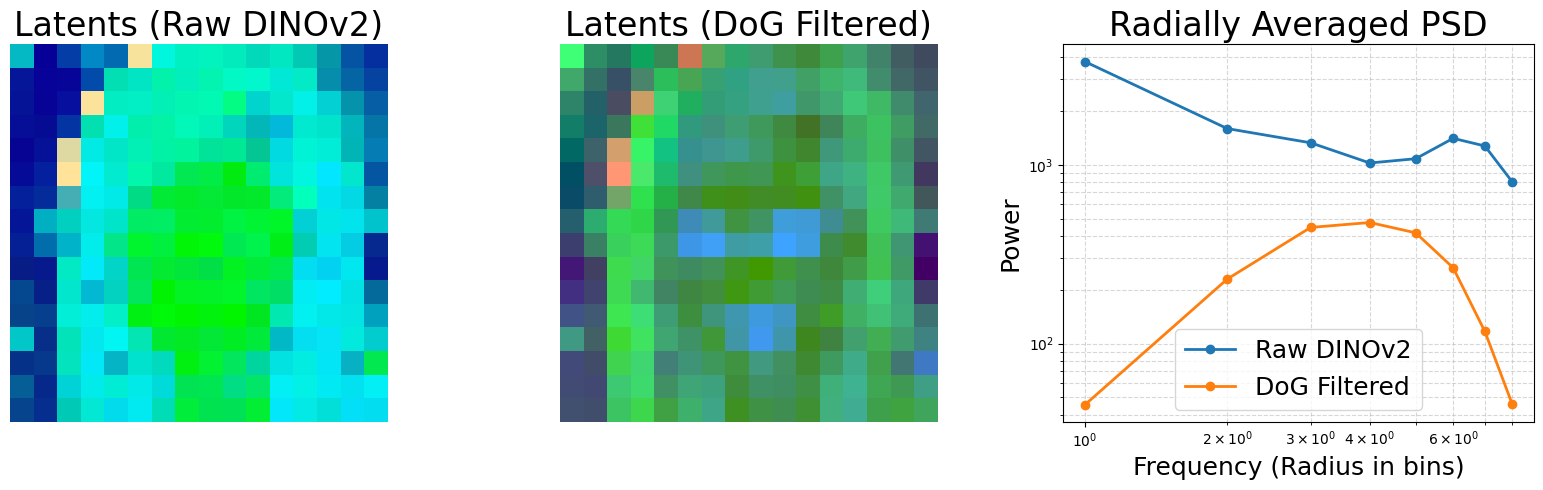

In [10]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from torch.utils.data import DataLoader
from torchvision.transforms.functional import gaussian_blur
from torchvision import transforms
from PIL import Image

from repa.config import ExperimentConfig
from repa.dataset import get_celeba_dataloader
from repa.models import REPAWrapper
from repa.models.factory import build_student_model


config = ExperimentConfig.from_defaults()
student_model, meta = build_student_model(config.model_type)
wrapper = REPAWrapper(student_model=student_model, meta=meta, config=config)

dataloader: DataLoader = get_celeba_dataloader("./../../data/", batch_size=1)
for batch in dataloader:
    image = batch[0].to(wrapper.device)
    break
z_0 = wrapper.get_teacher_features(image) 

def radial_power_spectrum(image):
    # 1. Ensure input is 4D: (Batch, Channels, Height, Width)
    if image.dim() == 3:
        image = image.unsqueeze(0)
        
    # CAST TO FLOAT32 to prevent torch.fft Half precision errors
    image = image.to(torch.float32)
    
    B, C, H, W = image.shape
    
    # 2. Compute 2D FFT and shift center
    f_coeffs = torch.fft.fft2(image, dim=(-2, -1))
    f_shifted = torch.fft.fftshift(f_coeffs, dim=(-2, -1))
    
    # 3. Calculate Power Spectrum: |F(u,v)|^2
    power_2d = torch.abs(f_shifted)**2
    power_2d = power_2d.mean(dim=1) 
    
    # 4. Create radial coordinate grid
    yc, xc = H // 2, W // 2
    y, x = torch.meshgrid(torch.arange(H) - yc, torch.arange(W) - xc, indexing='ij')
    r = torch.sqrt(x**2 + y**2).to(image.device)
    
    # 5. Binning setup
    r_int = r.round().long()
    max_r = int(min(H, W) / 2)
    
    valid_mask = r_int <= max_r
    
    # 6. Accumulate power per radius, per batch
    psd_1d = torch.zeros(B, max_r + 1, device=image.device)
    counts = torch.zeros(max_r + 1, device=image.device)
    
    power_flat = power_2d.view(B, -1)
    r_flat = r_int.flatten()
    
    r_valid = r_flat[valid_mask.flatten()]
    power_valid = power_flat[:, valid_mask.flatten()]
    
    r_expanded = r_valid.unsqueeze(0).expand(B, -1)
    psd_1d.scatter_add_(1, r_expanded, power_valid)
    counts.scatter_add_(0, r_valid, torch.ones_like(r_valid, dtype=torch.float32))
    
    # 7. Normalize by counts
    psd_1d = psd_1d / (counts.unsqueeze(0) + 1e-8)
    
    return psd_1d

def visualize_dog_filter(z_0):
    B, N, D = z_0.shape
    H = W = int(N ** 0.5)
    
    # Reshape to spatial grid: [1, 768, 16, 16]
    z_spatial = z_0.transpose(1, 2).view(1, D, H, W)
    
    # Apply DoG filters
    blur1 = gaussian_blur(z_spatial, kernel_size=[3, 3], sigma=[0.6, 0.6])
    blur2 = gaussian_blur(z_spatial, kernel_size=[5, 5], sigma=[2, 2])
    z_dog = blur1 - blur2
    
    # --- Helper: PCA to RGB for Spatial Visualization ---
    def to_rgb_pca(tensor):
        # Cast to float32 for stable PCA computation
        flat = tensor[0].permute(1, 2, 0).reshape(-1, D).cpu().to(torch.float32).numpy()
        pca = PCA(n_components=3)
        pca_features = pca.fit_transform(flat)
        pca_features = (pca_features - pca_features.min(axis=0)) / (pca_features.max(axis=0) - pca_features.min(axis=0))
        return pca_features.reshape(H, W, 3)

    # Compute visuals
    rgb_raw = to_rgb_pca(z_spatial)
    rgb_dog = to_rgb_pca(z_dog)
    
    # Compute PSDs
    psd_raw = radial_power_spectrum(z_spatial)
    psd_dog = radial_power_spectrum(z_dog)

    # --- Plotting ---
    fig = plt.figure(figsize=(16, 5))
    
    # 1. Raw Spatial
    ax1 = fig.add_subplot(1, 3, 1)
    ax1.imshow(rgb_raw)
    ax1.set_title("Latents (Raw DINOv2)", fontsize=24)
    ax1.axis('off')
    
    # 2. DoG Spatial
    ax2 = fig.add_subplot(1, 3, 2)
    ax2.imshow(rgb_dog)
    ax2.set_title("Latents (DoG Filtered)", fontsize=24)
    ax2.axis('off')
    
    # 3. PSD Plot overlay
    ax3 = fig.add_subplot(1, 3, 3)
    psd_dict = {"Raw DINOv2": psd_raw, "DoG Filtered": psd_dog}
    
    for label, psd_1d in psd_dict.items():
        psd_to_plot = psd_1d[0].cpu().numpy()
        # Start at 1 to skip the DC component for log-log plot
        freqs = np.arange(1, len(psd_to_plot))
        psd_to_plot = psd_to_plot[1:] 
        ax3.loglog(freqs, psd_to_plot, label=label, linewidth=2, marker='o', markersize=6)
    
    ax3.set_title("Radially Averaged PSD", fontsize=24)
    ax3.set_xlabel("Frequency (Radius in bins)", fontsize=18)
    ax3.set_ylabel("Power", fontsize=18)
    ax3.tick_params(axis='both', which='major', labelsize=10)
    ax3.tick_params(axis='both', which='minor', labelsize=10)
    ax3.grid(True, which="both", ls="--", alpha=0.5)
    ax3.legend(fontsize=18)
    
    plt.tight_layout()
    
    plt.savefig("./dog_filter.pdf", format="pdf")
    plt.show()
    
# Run it
visualize_dog_filter(z_0)